<div>
<img src="https://www.ul.ie/themes/custom/ul/logo.svg" width="350"/>
</div> 

## ET5003  Machine Learning Applications
## SEM1 2025/2026

### ET5003 Assignment #2 - Probability and Bayesian Inference

### Instructor: Emil Vassev
Oct 9th, 2025
<br><br>
Copyright (C) 2025 - All rights reserved, do not copy or distribute without permission of the author.
***

## Submission Info
### Student Name: <span style="color:red">David</span>
### Student Surname: <span style="color:red">Sheridan</span>
### Student ID: <span style="color:red">24300446</span>
### Date of Final Submission: <span style="color:red">02/11/2025</span>
***

# Task #1 (50%)

## Introduction
Suppose you have a bag full of diamonds of different cut, color, clarity. You draw diamonds without replacement.

In this task, you are asked to implement a Python code that will determine the probability of getting diamonds of a specific cut, color and clarity. 

## The Dataset
The diamonds data can be loaded from the online repository hosted by the seaborn Python library. 

The provided dataset can be loaded as following:

In [31]:
import seaborn as sns

df = sns.load_dataset('diamonds')

df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


## Computing Probability

Use the ```fractions``` library, which provides support for rational number arithmetic. Use the ```compute_probability``` function to calculate probability. 

For more information on ```fractions```, please consult the reference page here: https://docs.python.org/3/library/fractions.html#fractions.Fraction

In [34]:
from fractions import Fraction

cases = len # the number of cases is the length, or size, of a set
favorable = set.intersection # outcomes that are in the event and in the sample space

def compute_probability(event, space): ### The probability of an event, given a sample space.

    result = Fraction(cases(favorable(event, space)), cases(space))
    probability = result.numerator / result.denominator
    
    return probability

# Step 1: Determine the Sample Space Parameters.  (5%)

<span style="color:red">TODO</span>

Define the Diamonds Sample Space as:
* total number of diamonds
* total number of diamonds in category of cut
* total number of diamonds in category of color
* total number of diamonds in category of clarity

In [38]:
total_diamonds = len(df)
total_cuts = df['cut'].nunique()
total_colors = df['color'].nunique()
total_clarities = df['clarity'].nunique()

print("Total diamonds:", total_diamonds)
print("Unique cut categories:", total_cuts)
print("Unique color categories:", total_colors)
print("Unique clarity categories:", total_clarities)

Total diamonds: 53940
Unique cut categories: 5
Unique color categories: 7
Unique clarity categories: 8


# Step 2: Implement the Sample Space.  (15%)

<span style="color:red">TODO</span>

Implement a loop that will read the dataframe ```df``` and complete the ```diamonds``` sample space. The sample space must contain strings describing each diamond in the bag in terms of cut, color, and clarity.

In [41]:
diamonds = {}

#Constructing the sample space
for i, row in df.iterrows():
    diamonds[i] = f"{row['cut']}_{row['color']}_{row['clarity']}"

#Displaying first few entries
print("\nSample space preview:")
for k in list(diamonds.keys())[:5]:
    print(f"{k}: {diamonds[k]}")

#Helper functions for computing probabilities
cases = len #Total number of cases in a set
favorable = set.intersection #Intersection = favorable outcomes

def compute_probability(event, space): #Compute the probability of an event given a sample space using Fraction arithmetic. Returns the probability as a decimal.
    result = Fraction(cases(favorable(event, space)), cases(space))
    probability = result.numerator / result.denominator
    return probability

#Converting the dictionary values into a set for set operations
space = set(diamonds.values())



Sample space preview:
0: Ideal_E_SI2
1: Premium_E_SI1
2: Good_E_VS1
3: Premium_I_VS2
4: Good_J_SI2


# Step 3: Implement Events and Compute Probabilites.  (30%)

## Step 3.1: Compute the Probability of Drawing Five Diamonds with "Ideal" Cut Consecutively?   (10%)

<span style="color:red">TODO</span>

* implement the event "diamonds with ideal cut"
* compute the probability of drawing five diamonds with "ideal" cut consecutively and without replacement 

In [54]:
from fractions import Fraction
from math import comb

#Ensuring space is correct
space = set(diamonds.keys())
N = len(space)
print("Total diamonds (N):", N)  # should print 53940

#All indices whose cut is "Ideal"
ev_diamonds_with_ideal_cut = {
    i for i, desc in diamonds.items()
    if desc.split('_')[0].strip().upper() == "IDEAL"
}
count_ideal = len(ev_diamonds_with_ideal_cut)
print("Number of 'Ideal' cut diamonds:", count_ideal)  # ~21551

#Exact probability: 5 Ideals without replacement
p5_ideal = Fraction(comb(count_ideal, 5), comb(N, 5))

print("Fraction form:", p5_ideal)
print(f"Probability (scientific): {float(p5_ideal):.10e}")
print(f"Probability (percentage): {float(p5_ideal)*100:.4f}%")

#Quick sanity approximation
approx_power = (count_ideal / N) ** 5
print(f"Approximation using (p)^5: {approx_power:.10e}")




Total diamonds (N): 53940
Number of 'Ideal' cut diamonds: 21551
Fraction form: 1335230847375387215/131188253398245109872
Probability (scientific): 1.0177975640e-02
Probability (percentage): 1.0178%
Approximation using (p)^5: 1.0180812144e-02


## Step 3.2: Compute the Probability of Drawing Five Diamonds with "SI2" Clarity Consecutively?   (10%)

<span style="color:red">TODO</span>

* implement the event "diamonds with SI2 clarity"
* compute the probability of drawing five diamonds with "SI2" clarity consecutively and without replacement

In [57]:
#Select all diamonds whose clarity is "SI2"
ev_diamonds_with_si2_clarity = {
    i for i, desc in diamonds.items()
    if desc.split('_')[-1].strip().upper() == "SI2"
}

count_si2 = len(ev_diamonds_with_si2_clarity) #favourable outcomes
N = len(space) #total diamonds

print(f"Number of 'SI2' clarity diamonds: {count_si2}")
print(f"Total diamonds: {N}")

#Hypergeometric probability: P = C(f,5) / C(N,5)
p5_si2 = Fraction(comb(count_si2, 5), comb(N, 5))

#Displaying results
print("Fraction form:", p5_si2)
print(f"Probability (scientific): {float(p5_si2):.10e}")
print(f"Probability (percentage): {float(p5_si2) * 100:.6f}%")

#Quick approximation check
approx_power = (count_si2 / N) ** 5
print(f"Approximation using (p)^5: {approx_power:.10e}")



Number of 'SI2' clarity diamonds: 9194
Total diamonds: 53940
Fraction form: 362633118810011/2522851026889329036
Probability (scientific): 1.4373941027e-04
Probability (percentage): 0.014374%
Approximation using (p)^5: 1.4386918603e-04


## Step 3.3: Compute the Probability of Drawing Five Diamonds with "E" Color Consecutively?   (5%)

<span style="color:red">TODO</span>

* implement the event "diamonds with E color"
* compute the probability of drawing five diamonds with "E" color consecutively and without replacement

In [59]:
ev_diamonds_with_e_color = {
    i for i, desc in diamonds.items()
    if desc.split('_')[1].strip().upper() == "E"
}

#Counts
count_e = len(ev_diamonds_with_e_color)
N = len(space)

print(f"Number of 'E' color diamonds: {count_e}")
print(f"Total diamonds: {N}")

#Probability computation (hypergeometric)
p5_e = Fraction(comb(count_e, 5), comb(N, 5))

#Displaying results
print("Fraction form:", p5_e)
print(f"Probability (scientific): {float(p5_e):.10e}")
print(f"Probability (percentage): {float(p5_e) * 100:.6f}%")

#Quick approximation
approx_power = (count_e / N) ** 5
print(f"Approximation using (p)^5: {approx_power:.10e}")

Number of 'E' color diamonds: 9797
Total diamonds: 53940
Fraction form: 24237020999790319/122724495114487360848
Probability (scientific): 1.9749130748e-04
Probability (percentage): 0.019749%
Approximation using (p)^5: 1.9765637658e-04


## Step 3.4: Compute the Probability of Drawing Five Diamonds with "Ideal" cut, "SI2" Clarity, and "E" Color Consecutively?   (5%)

<span style="color:red">TODO</span>

* implement the event "diamonds with Ideal cut, SI2 clarity, and E color"
* compute the probability of drawing five diamonds with "Ideal" cut, "SI2" clarity, and "E" color consecutively and without replacement

In [61]:
ev_diamonds_with_ideal_cut_si2_clarity_e_color = {
    i for i, desc in diamonds.items()
    if (lambda parts: len(parts) == 3 and
        parts[0].strip().upper() == "IDEAL" and
        parts[1].strip().upper() == "E" and
        parts[2].strip().upper() == "SI2")(desc.split('_'))
}

#Counts
count_combo = len(ev_diamonds_with_ideal_cut_si2_clarity_e_color)
N = len(space)

print(f"Number of 'Ideal_E_SI2' diamonds: {count_combo}")
print(f"Total diamonds: {N}")

#Probability (hypergeometric)
#If fewer than 5 exist, probability is 0 by definition.
if count_combo >= 5:
    p5_combo = Fraction(comb(count_combo, 5), comb(N, 5))
else:
    p5_combo = Fraction(0, 1)

#Displaying Results
print("Fraction form:", p5_combo)
print(f"Probability (scientific): {float(p5_combo):.10e}")
print(f"Probability (percentage): {float(p5_combo) * 100:.10f}%")

#Quick approximation
approx_power = (count_combo / N) ** 5 if count_combo > 0 else 0.0
print(f"Approximation using (p)^5: {approx_power:.10e}")

Number of 'Ideal_E_SI2' diamonds: 469
Total diamonds: 53940
Fraction form: 51032359/1048927308670832144
Probability (scientific): 4.8651950024e-11
Probability (percentage): 0.0000000049%
Approximation using (p)^5: 4.9694634757e-11


In [67]:
def hypergeom_5(f, N):
    return Fraction(comb(f,5), comb(N,5)) if f >= 5 else Fraction(0,1)

N = len(space)

# counts from events
count_ideal = len(ev_diamonds_with_ideal_cut)
count_si2   = len(ev_diamonds_with_si2_clarity)
count_e     = len(ev_diamonds_with_e_color)
count_combo = len(ev_diamonds_with_ideal_cut_si2_clarity_e_color)

rows = [
    ("5 × Ideal",            count_ideal, float(hypergeom_5(count_ideal, N))),
    ("5 × SI2",              count_si2,   float(hypergeom_5(count_si2,   N))),
    ("5 × E",                count_e,     float(hypergeom_5(count_e,     N))),
    ("5 × Ideal+E+SI2",      count_combo, float(hypergeom_5(count_combo, N))),
]

print("Summary (exact hypergeometric)")
for name, f, p in rows:
    print(f"{name:18} | count={f:6d} | P = {p:.10e}  ({p*100:.8f}%)")

Summary (exact hypergeometric)
5 × Ideal          | count= 21551 | P = 1.0177975640e-02  (1.01779756%)
5 × SI2            | count=  9194 | P = 1.4373941027e-04  (0.01437394%)
5 × E              | count=  9797 | P = 1.9749130748e-04  (0.01974913%)
5 × Ideal+E+SI2    | count=   469 | P = 4.8651950024e-11  (0.00000000%)


# Task #2 (50%)

## Introduction

### Milk Production in Limerick, Ireland

Mr. Collins, an Irish farmer from Limerick, has a herd of 12 dairy cows. He is producing milk daily and measures the litres of milk his cows produce for a month. Below is the milk produced for the last month, per cow.

Milk = [651, 374, 601, 401, 767, 450, 342, 677, 567, 687, 445, 512]

Mr. Collins would like to know how much milk a cow is expected to produce on average. 

For this, a statistician friend looks at the county production of milk, considering the entire population of dairy caws in Limerick. In Limerick County, there are **125,411** dairy caws with a lowest monthly milk production for a caw of **245** litres and maximum milk production of **878** litres. The monthly milk production is measured in **whole litres**.


The statistician decides to use the Bayesian Inference technique where milk is assumed to be normally distributed for the prior and likelihood distributions. For the milk spread in Limerick (normalization factor), the statistician decides to use the uniform distribution. 


Calculate the posterior milk distribution for Mr. Collins's farm. For the population of dairy caws in Ireland and their milk production per month, use the **numpy.linspace()** method.

## Bayesian Inference

Inference - using statistics to deduce properties about a probability distribution from data.

Bayes’ Theorem works not on events but on distributions:
* Θ - set of parameters
* P(Θ) - prior distribution, or distribution of our belief about the true value of Θ
* P(Θ|data) - posterior distribution, or distribution of our belief about Θ after we have taken the observed data into account
* P(data|Θ) - likelihood distribution measures the degree to which data supports Θ
* P(data) - normalization distribution, i.e., is the total probability of the data taking into account all possible hypotheses 
<pre>
              P(data|Θ) * P(Θ)
   P(Θ|data) = -----------------
		          P(data)                                 
</pre>

## Your Solution to Task #2 (50%)

Notes:

We infer the farm's true average monthly milk per cow, μ.

Likelihood: y_i | μ ~ Normal(μ, σ^2) with σ estimated from sample sd.

Prior: μ ~ Normal(μ0, σ0^2) using county range [245, 878] L.

Evidence/normalisation: handled explicitly in a θ-grid via numpy.linspace as requested.

Outputs:
Closed-form posterior: mean, sd, 95% credible interval.

Grid posterior: mean, sd (matches closed-form).

Posterior-predictive for a new cow: mean, sd, 95% predictive interval.

In [72]:
import numpy as np
from math import sqrt
np.set_printoptions(precision=3, suppress=True)

#Data: monthly litres for Mr. Collins' 12 cows
milk = np.array([651, 374, 601, 401, 767, 450, 342, 677, 567, 687, 445, 512], dtype=float)

n = len(milk)
ybar = milk.mean()
sigma = milk.std(ddof=1)  #sample sd for likelihood scale

print(f"n (cows)     : {n}")
print(f"Sample mean  : {ybar:.3f} L")
print(f"Sample sd    : {sigma:.3f} L")

n (cows)     : 12
Sample mean  : 539.500 L
Sample sd    : 139.044 L


Prior from county information (Limerick)

County range: min = 245 L, max = 878 L (whole litres).

We'll center prior at the midpoint and choose σ0 so ~95% prior mass covers the range:

μ0 = (245 + 878)/2

4*σ0 ≈ (878 - 245) → σ0 = (878 - 245)/4

In [78]:
low, high = 245.0, 878.0

mu0 = (low + high) / 2.0 #prior mean
sigma0 = (high - low) / 4.0 #prior sd (~95% mass across the given range)

print(f"Prior mean μ0 : {mu0:.3f} L")
print(f"Prior sd σ0 : {sigma0:.3f} L")

Prior mean μ0 : 561.500 L
Prior sd σ0 : 158.250 L


Closed-form (Normal–Normal) posterior for μ with known σ

Posterior is Normal with:

σ_n^2 = 1 / ( n/σ^2 + 1/σ0^2 )

μ_n   = σ_n^2 * ( μ0/σ0^2 + n*ȳ/σ^2 )

We'll report μ_n, σ_n, and a 95% credible interval.

In [81]:
#closed-form posterior
sigma_n2 = 1.0 / (n/(sigma**2) + 1.0/(sigma0**2))
sigma_n = sqrt(sigma_n2)
mu_n = sigma_n2 * (mu0/(sigma0**2) + n*ybar/(sigma**2))

lo95, hi95 = mu_n - 1.96*sigma_n, mu_n + 1.96*sigma_n

print(f"Posterior μ | data ~ Normal(mean={mu_n:.3f}, sd={sigma_n:.3f})")
print(f"95% credible interval for μ: [{lo95:.1f}, {hi95:.1f}] L")

Posterior μ | data ~ Normal(mean=540.830, sd=38.907)
95% credible interval for μ: [464.6, 617.1] L


Grid (linspace) posterior for μ over [245, 878] (as required)

We approximate p(μ|data) ∝ Likelihood(μ) × Prior(μ) on a uniform θ-grid

and then normalise with trapezoidal integration.

Likelihood in μ uses the sampling distribution of the sample mean ȳ:

ȳ | μ ~ Normal(μ, σ^2/n)  → L(μ) ∝ exp( -0.5 * ((μ - ȳ)/(σ/√n))^2 )

In [84]:
theta = np.linspace(low, high, 2000)  #dense grid over population range

like = np.exp(-0.5 * ((theta - ybar) / (sigma/np.sqrt(n)))**2) #likelihood over μ
prior = np.exp(-0.5 * ((theta - mu0) / sigma0)**2) #prior over μ

post_unnorm = like * prior
Z = np.trapz(post_unnorm, theta) #evidence
post = post_unnorm / Z #normalised posterior

#posterior mean/sd via numerical integration
post_mean = np.trapz(theta * post, theta)
post_var = np.trapz((theta - post_mean)**2 * post, theta)
post_sd = np.sqrt(post_var)

print(f"Grid posterior mean: {post_mean:.3f} L")
print(f"Grid posterior sd: {post_sd:.3f} L")

Grid posterior mean: 540.830 L
Grid posterior sd: 38.907 L


Posterior-predictive for a new cow on Mr. Collins' farm 

With known σ, the predictive distribution is:

y_new | data ~ Normal( μ_n, σ^2 + σ_n^2 )

We'll report the predictive mean, sd, and a 95% predictive interval.

In [87]:
sigma_pred = np.sqrt(sigma**2 + sigma_n**2)
plo, phi = mu_n - 1.96*sigma_pred, mu_n + 1.96*sigma_pred

print(f"Posterior-predictive y_new ~ Normal(mean={mu_n:.1f}, sd={sigma_pred:.1f})")
print(f"95% predictive interval for a new cow: [{plo:.1f}, {phi:.1f}] L")

Posterior-predictive y_new ~ Normal(mean=540.8, sd=144.4)
95% predictive interval for a new cow: [257.8, 823.8] L


Quick visual check

Plot prior, likelihood-in-μ (scaled), and posterior on [245, 878] to show the update.

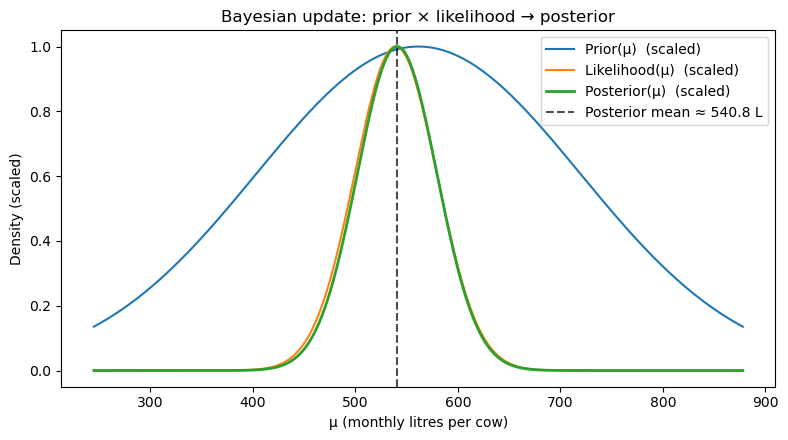

In [91]:
import matplotlib.pyplot as plt

#scale curves for visual comparability
like_scaled  = like / like.max()
prior_scaled = prior / prior.max()
post_scaled  = post  / post.max()

plt.figure(figsize=(8,4.5))
plt.plot(theta, prior_scaled, label="Prior(μ)  (scaled)")
plt.plot(theta, like_scaled, label="Likelihood(μ)  (scaled)")
plt.plot(theta, post_scaled, label="Posterior(μ)  (scaled)", linewidth=2)
plt.axvline(mu_n, color='k', linestyle='--', alpha=0.7, label=f"Posterior mean ≈ {mu_n:.1f} L")
plt.xlabel("μ (monthly litres per cow)")
plt.ylabel("Density (scaled)")
plt.title("Bayesian update: prior × likelihood → posterior")
plt.legend()
plt.tight_layout()
plt.show()

The plot illustrates how Mr. Collins’s farm data refines the county-level prior knowledge.

The posterior is narrower than the prior, showing reduced uncertainty after observing the 12 cows.

The posterior mean (≈ 540.8 L) lies slightly below the prior mean (561.5 L), consistent with the farm producing marginally less milk than the county average.

The predictive interval for a new cow (≈ [258 L, 824 L]) reflects individual variability rather than uncertainty in the mean.